# GLM 廣義線性模型：計算原理、數學推導與 Python 實作

本 Notebook 以「廣義線性模型（GLM）計算原理與數學推導教材」為藍本，將原本的 Markdown 教材整理成可執行的 Jupyter Notebook。

本教材分成三個部分：

1. GLM 的基本概念、數學結構與模型估計邏輯。
2. Vanilla / NumPy 版本：以 logistic regression 為例，手動實作 sigmoid、log-likelihood、gradient descent 與預測。
3. 套件版本：使用 `statsmodels` 的 `GLM` 類別估計 Binomial-logit GLM，並示範 Poisson-log GLM。

> 說明：GLM 是一個模型家族，不是單一模型。線性迴歸、logistic regression、Poisson regression 都可以被放在 GLM 框架下理解。


## 0. 環境設定

本 Notebook 使用下列套件：

- `numpy`：矩陣與數值運算。
- `pandas`：表格整理。
- `matplotlib`：視覺化。
- `statsmodels`：統計模型估計與 GLM 套件版本示範。

若尚未安裝，可執行：

```python
%pip install numpy pandas matplotlib statsmodels
```


以下內容保留原始教材的主要章節，並轉換為 Notebook 的 Markdown 說明。

# 廣義線性模型（GLM）計算原理與數學推導教材

## 1. GLM 是什麼？

廣義線性模型（Generalized Linear Model, GLM）是一種用來分析「自變數如何影響依變數」的統計模型。它可以視為傳統線性迴歸的延伸，特別適合處理依變數不是連續常態分配的情況。

傳統線性迴歸通常假設依變數為連續變數，且誤差項接近常態分配。例如研究「讀書時間」對「考試成績」的影響時，考試成績可以用一般線性迴歸處理。

然而，在許多管理、資訊系統、社會科學與醫學研究中，依變數可能是：

- 是否採用某項系統：是／否
- 使用者是否持續使用 AI 工具：持續／不持續
- 顧客抱怨次數：0 次、1 次、2 次、3 次
- 某事件發生機率：發生／未發生
- 單位時間內的錯誤次數或事故次數

這些資料型態未必符合傳統線性迴歸的常態假設。因此，GLM 透過「機率分配」與「連結函數」將線性模型推廣到更多類型的依變數。

白話來說，GLM 的核心想法是：

> 仍然保留線性模型容易解釋的結構，但允許依變數有不同的資料分配型態。

---

## 2. 傳統線性迴歸的基本形式

在理解 GLM 之前，可以先從傳統線性迴歸開始。

假設研究者想分析使用者的系統滿意度 $Y$，是否受到感知有用性 $X_1$、感知易用性 $X_2$ 與信任 $X_3$ 的影響。

傳統線性迴歸可表示為：

$$
Y_i=\beta_0+\beta_1X_{i1}+\beta_2X_{i2}+\beta_3X_{i3}+\varepsilon_i
$$

其中：

- $Y_i$：第 $i$ 位受測者的依變數數值
- $X_{i1},X_{i2},X_{i3}$：第 $i$ 位受測者在不同自變數上的分數
- $\beta_0$：截距項
- $\beta_1,\beta_2,\beta_3$：迴歸係數
- $\varepsilon_i$：誤差項

若有 $p$ 個自變數，則可寫成一般形式：

$$
Y_i=\beta_0+\beta_1X_{i1}+\beta_2X_{i2}+\cdots+\beta_pX_{ip}+\varepsilon_i
$$

也可以將右側線性組合記為：

$$
\eta_i=\beta_0+\sum_{k=1}^{p}\beta_kX_{ik}
$$

其中，$\eta_i$ 稱為線性預測值（linear predictor）。

在線性迴歸中，模型通常假設：

$$
Y_i\sim N(\mu_i,\sigma^2)
$$

且：

$$
\mu_i=E(Y_i)=\eta_i
$$

也就是說，依變數的期望值 $\mu_i$ 直接等於線性預測值 $\eta_i$。

---

## 3. 為什麼需要 GLM？

傳統線性迴歸雖然容易理解，但它對依變數有較強的假設。若依變數不是連續常態變數，直接使用線性迴歸可能產生不合理結果。

例如，若依變數是「是否持續使用 AI 工具」，可設定：

$$
Y_i=1
$$

表示第 $i$ 位使用者持續使用。

$$
Y_i=0
$$

表示第 $i$ 位使用者未持續使用。

若直接用線性迴歸預測，模型可能得到：

$$
\hat{Y}_i=1.23
$$

或：

$$
\hat{Y}_i=-0.18
$$

但二元變數的合理預測值應該落在 0 到 1 之間，因為它通常代表事件發生的機率。

同樣地，若依變數是「某位使用者一週內遇到系統錯誤的次數」，該變數應為非負整數：

$$
Y_i=0,1,2,3,\ldots
$$

此時若用一般線性迴歸，模型可能預測出負數錯誤次數，這也不具實際意義。

因此，GLM 的目的不是放棄線性模型，而是修正線性模型與依變數之間的關係，使模型更符合不同資料型態。

---

## 4. GLM 的三個核心組成

GLM 主要由三個部分組成：

1. 隨機成分（random component）
2. 系統成分（systematic component）
3. 連結函數（link function）

這三個部分共同決定 GLM 如何描述資料。

---

## 5. 隨機成分：依變數的機率分配

GLM 的第一個核心，是指定依變數 $Y_i$ 服從哪一種機率分配。

在線性迴歸中，常假設：

$$
Y_i\sim N(\mu_i,\sigma^2)
$$

也就是依變數服從常態分配。

但在 GLM 中，依變數可以服從指數族分配（exponential family）中的不同分配，例如：

| 依變數型態 | 常用分配 | 常見模型 |
|---|---|---|
| 連續變數 | Normal distribution | 線性迴歸 |
| 二元變數 | Bernoulli distribution | Logistic regression |
| 成功次數／比例 | Binomial distribution | Logistic regression |
| 計數資料 | Poisson distribution | Poisson regression |
| 過度離散計數資料 | Negative binomial distribution | 負二項迴歸 |
| 正值且右偏連續資料 | Gamma distribution | Gamma regression |

例如，若依變數是使用者是否持續使用系統，可設定：

$$
Y_i\sim Bernoulli(\pi_i)
$$

其中，$\pi_i$ 表示第 $i$ 位使用者持續使用系統的機率。

若依變數是某位使用者一個月內回報錯誤的次數，可設定：

$$
Y_i\sim Poisson(\mu_i)
$$

其中，$\mu_i$ 表示第 $i$ 位使用者在該期間內的期望錯誤次數。

---

## 6. 系統成分：自變數的線性組合

GLM 的第二個核心，是保留線性模型的結構。

不論依變數服從哪一種分配，自變數仍然透過線性組合形成線性預測值：

$$
\eta_i=\beta_0+\beta_1X_{i1}+\beta_2X_{i2}+\cdots+\beta_pX_{ip}
$$

或簡寫為：

$$
\eta_i=\mathbf{x}_i^T\boldsymbol{\beta}
$$

其中：

$$
\mathbf{x}_i=(1,X_{i1},X_{i2},\ldots,X_{ip})^T
$$

$$
\boldsymbol{\beta}=(\beta_0,\beta_1,\beta_2,\ldots,\beta_p)^T
$$

因此：

$$
\mathbf{x}_i^T\boldsymbol{\beta}
=
\beta_0+\beta_1X_{i1}+\beta_2X_{i2}+\cdots+\beta_pX_{ip}
$$

這個部分使 GLM 仍然具有迴歸分析的解釋能力。研究者仍可透過 $\beta_k$ 判斷某個自變數對依變數的影響方向與強度。

---

## 7. 連結函數：把平均數與線性預測值連起來

GLM 的第三個核心，是連結函數（link function）。

在 GLM 中，依變數的期望值記為：

$$
\mu_i=E(Y_i)
$$

但 $\mu_i$ 不一定能直接等於線性預測值 $\eta_i$。因此 GLM 使用連結函數 $g(\cdot)$，將 $\mu_i$ 轉換成線性預測值：

$$
g(\mu_i)=\eta_i
$$

也就是：

$$
g(\mu_i)=\beta_0+\beta_1X_{i1}+\beta_2X_{i2}+\cdots+\beta_pX_{ip}
$$

若要從線性預測值回到依變數的期望值，則使用反連結函數（inverse link function）：

$$
\mu_i=g^{-1}(\eta_i)
$$

白話來說，連結函數的作用是：

> 讓不適合直接用直線表示的依變數平均值，能夠被轉換到適合線性建模的尺度上。

例如，在 logistic regression 中，依變數是 0 或 1，事件機率 $\pi_i$ 必須介於 0 與 1 之間。此時模型不直接讓 $\pi_i$ 等於線性預測值，而是先將機率轉換成 log odds。

---

## 8. GLM 的一般形式

綜合上述三個部分，GLM 的一般形式可表示為：

第一，依變數服從某種分配：

$$
Y_i\sim F(\mu_i,\phi)
$$

其中，$F$ 表示某個指數族分配，$\mu_i$ 為期望值，$\phi$ 為離散參數或尺度參數。

第二，建立線性預測值：

$$
\eta_i=\mathbf{x}_i^T\boldsymbol{\beta}
$$

第三，透過連結函數連接期望值與線性預測值：

$$
g(\mu_i)=\eta_i
$$

因此 GLM 的核心結構可整理為：

$$
g(E(Y_i))=\mathbf{x}_i^T\boldsymbol{\beta}
$$

這個式子是 GLM 最重要的概念。

它表示：

> 不是直接讓依變數等於自變數的線性組合，而是讓依變數的期望值經過連結函數後，等於自變數的線性組合。

---

## 9. Logistic regression：二元依變數的 GLM

Logistic regression 是最常見的 GLM 之一，適合依變數為二元結果的情境。

例如，研究者想分析使用者是否持續使用某 AI 寫作工具：

$$
Y_i=1
$$

表示持續使用。

$$
Y_i=0
$$

表示未持續使用。

此時可設定：

$$
Y_i\sim Bernoulli(\pi_i)
$$

其中：

$$
\pi_i=P(Y_i=1)
$$

表示第 $i$ 位使用者持續使用的機率。

由於 $\pi_i$ 必須介於 0 與 1 之間，不能直接令：

$$
\pi_i=\beta_0+\beta_1X_{i1}+\cdots+\beta_pX_{ip}
$$

否則可能預測出小於 0 或大於 1 的機率。

因此 logistic regression 使用 logit link：

$$
g(\pi_i)=\log\left(\frac{\pi_i}{1-\pi_i}\right)
$$

模型可寫為：

$$
\log\left(\frac{\pi_i}{1-\pi_i}\right)
=
\beta_0+\beta_1X_{i1}+\beta_2X_{i2}+\cdots+\beta_pX_{ip}
$$

其中：

$$
\frac{\pi_i}{1-\pi_i}
$$

稱為 odds，也就是事件發生機率與事件未發生機率的比值。

若將模型轉回機率尺度，可得到：

$$
\pi_i=
rac{e^{\eta_i}}{1+e^{\eta_i}}
$$

或：

$$
\pi_i=\frac{1}{1+e^{-\eta_i}}
$$

這個轉換可以保證預測機率一定落在 0 到 1 之間。

---

## 10. Logistic regression 係數的解釋

在 logistic regression 中，$\beta_k$ 不是直接表示依變數增加多少，而是表示 log odds 的變化。

若模型為：

$$
\log\left(\frac{\pi_i}{1-\pi_i}\right)
=
\beta_0+\beta_1X_{i1}
$$

當 $X_{i1}$ 增加 1 單位時，log odds 會增加 $\beta_1$。

若將 $\beta_1$ 取指數，可得到 odds ratio：

$$
OR=e^{\beta_1}
$$

若：

$$
\beta_1=0.7
$$

則：

$$
OR=e^{0.7}\approx 2.01
$$

表示 $X_1$ 每增加 1 單位，事件發生的 odds 約為原本的 2.01 倍。

若：

$$
\beta_1<0
$$

則：

$$
e^{\beta_1}<1
$$

表示 $X_1$ 增加時，事件發生的 odds 下降。

因此，在解釋 logistic regression 時，常會同時報告：

- 迴歸係數 $\beta$
- 標準誤
- Wald test 或 z 值
- p 值
- odds ratio $e^\beta$
- 信賴區間

---

## 11. Poisson regression：計數資料的 GLM

Poisson regression 適合用於分析計數資料，例如：

- 使用者一週內開啟 App 的次數
- 員工一個月內回報系統錯誤的次數
- 工地一天內發生安全違規的次數
- 顧客一段期間內提出抱怨的次數

計數資料通常具有下列特徵：

$$
Y_i=0,1,2,3,\ldots
$$

也就是只能是非負整數。

Poisson regression 假設：

$$
Y_i\sim Poisson(\mu_i)
$$

其中，$\mu_i$ 表示事件發生次數的期望值。

由於 $\mu_i$ 必須大於 0，因此 Poisson regression 常使用 log link：

$$
g(\mu_i)=\log(\mu_i)
$$

模型可寫為：

$$
\log(\mu_i)=\beta_0+\beta_1X_{i1}+\beta_2X_{i2}+\cdots+\beta_pX_{ip}
$$

若轉回原本尺度：

$$
\mu_i=e^{\eta_i}
$$

這可以確保預測的期望次數一定為正數。

---

## 12. Poisson regression 係數的解釋

在 Poisson regression 中，$\beta_k$ 表示自變數對 log expected count 的影響。

若模型為：

$$
\log(\mu_i)=\beta_0+\beta_1X_{i1}
$$

當 $X_{i1}$ 增加 1 單位時，$\log(\mu_i)$ 增加 $\beta_1$。

若將係數取指數，可得到 incident rate ratio，常簡稱 IRR：

$$
IRR=e^{\beta_1}
$$

若：

$$
\beta_1=0.2
$$

則：

$$
IRR=e^{0.2}\approx 1.22
$$

表示 $X_1$ 每增加 1 單位，事件的期望發生次數約變成原本的 1.22 倍，也就是增加約 22%。

若：

$$
\beta_1=-0.3
$$

則：

$$
IRR=e^{-0.3}\approx 0.74
$$

表示 $X_1$ 每增加 1 單位，事件的期望發生次數約變成原本的 0.74 倍，也就是下降約 26%。

---

## 13. GLM 的參數估計：最大概似估計

傳統線性迴歸常可透過最小平方法（ordinary least squares, OLS）估計參數。但 GLM 通常使用最大概似估計（maximum likelihood estimation, MLE）。

最大概似估計的核心想法是：

> 找出一組參數，使目前觀察到的資料出現機率最大。

假設有 $n$ 筆獨立觀察資料：

$$
Y_1,Y_2,\ldots,Y_n
$$

且每一筆資料的機率函數為：

$$
f(y_i;\boldsymbol{\beta})
$$

則整體概似函數為：

$$
L(\boldsymbol{\beta})=\prod_{i=1}^{n}f(y_i;\boldsymbol{\beta})
$$

由於連乘計算較不方便，通常改用對數概似函數：

$$
\ell(\boldsymbol{\beta})=\log L(\boldsymbol{\beta})
$$

因此：

$$
\ell(\boldsymbol{\beta})=
\sum_{i=1}^{n}\log f(y_i;\boldsymbol{\beta})
$$

GLM 的估計目標是找到：

$$
\hat{\boldsymbol{\beta}}
=
\arg\max_{\boldsymbol{\beta}}\ell(\boldsymbol{\beta})
$$

也就是讓對數概似函數最大的參數估計值。

實務上，GLM 的參數通常透過數值最佳化方法求解，例如 Newton-Raphson 或 Fisher scoring。使用統計軟體時，這些計算會由軟體自動完成。

---

## 14. 以使用者是否持續使用 AI 工具為例說明計算邏輯

假設研究者想分析使用者是否持續使用 AI 工具，依變數為：

$$
Y_i=1
$$

表示持續使用。

$$
Y_i=0
$$

表示未持續使用。

自變數包含：

$$
X_1=\text{感知有用性}
$$

$$
X_2=\text{信任}
$$

$$
X_3=\text{使用焦慮}
$$

由於依變數為二元變數，可使用 logistic regression：

$$
Y_i\sim Bernoulli(\pi_i)
$$

其中：

$$
\pi_i=P(Y_i=1)
$$

模型設定為：

$$
\log\left(\frac{\pi_i}{1-\pi_i}\right)
=
\beta_0+\beta_1X_{i1}+\beta_2X_{i2}+\beta_3X_{i3}
$$

假設估計結果為：

$$
\hat{\beta}_0=-3.00
$$

$$
\hat{\beta}_1=0.80
$$

$$
\hat{\beta}_2=0.60
$$

$$
\hat{\beta}_3=-0.50
$$

則模型為：

$$
\log\left(\frac{\pi_i}{1-\pi_i}\right)
=
-3.00+0.80X_{i1}+0.60X_{i2}-0.50X_{i3}
$$

若某位使用者的分數為：

$$
X_{i1}=5
$$

$$
X_{i2}=4
$$

$$
X_{i3}=2
$$

則線性預測值為：

$$
\eta_i=-3.00+0.80(5)+0.60(4)-0.50(2)
$$

$$
\eta_i=-3.00+4.00+2.40-1.00
$$

$$
\eta_i=2.40
$$

接著將 $\eta_i$ 轉換為機率：

$$
\pi_i=\frac{1}{1+e^{-2.40}}
$$

由於：

$$
e^{-2.40}\approx 0.091
$$

所以：

$$
\pi_i\approx \frac{1}{1+0.091}
$$

$$
\pi_i\approx 0.916
$$

表示該使用者持續使用 AI 工具的預測機率約為 91.6%。

---

## 15. 常見連結函數整理

不同 GLM 會搭配不同的連結函數。常見整理如下：

| 依變數型態 | 分配 | 常用連結函數 | 模型形式 |
|---|---|---|---|
| 連續變數 | Normal | Identity link | $\mu_i=\eta_i$ |
| 二元變數 | Bernoulli / Binomial | Logit link | $\log\left(\frac{\pi_i}{1-\pi_i}\right)=\eta_i$ |
| 計數資料 | Poisson | Log link | $\log(\mu_i)=\eta_i$ |
| 正值右偏資料 | Gamma | Log link 或 inverse link | $\log(\mu_i)=\eta_i$ |
| 比例資料 | Binomial | Logit link | $\log\left(\frac{\pi_i}{1-\pi_i}\right)=\eta_i$ |

需要注意的是，分配與連結函數的選擇應根據研究問題、依變數型態與資料特性決定，而不是只根據研究者習慣選擇。

---

## 16. GLM 的模型檢查

建立 GLM 後，研究者需要檢查模型是否適合資料。常見檢查包括：

### 16.1 係數顯著性

可檢查每個自變數的係數是否顯著不等於 0。常見檢定包括：

- Wald test
- Likelihood ratio test
- Score test

若某個自變數的係數顯著，表示該變數與依變數之間存在統計上可檢測的關聯。

### 16.2 模型整體適配度

GLM 常使用 deviance 評估模型適配情形。Deviance 可理解為模型與飽和模型之間的差距。

一般來說，deviance 越小，表示模型與資料越接近。

也可使用資訊準則比較模型：

$$
AIC=-2\ell(\hat{\boldsymbol{\beta}})+2k
$$

其中：

- $\ell(\hat{\boldsymbol{\beta}})$：模型的最大對數概似值
- $k$：模型參數數量

AIC 越小，通常表示模型在解釋力與複雜度之間取得較佳平衡。

### 16.3 過度離散

在 Poisson regression 中，一個重要假設是：

$$
E(Y_i)=Var(Y_i)=\mu_i
$$

也就是平均數與變異數相等。

但實際資料中，計數變數常出現變異數大於平均數的情況，稱為過度離散（overdispersion）：

$$
Var(Y_i)>E(Y_i)
$$

若有明顯過度離散，Poisson regression 可能低估標準誤，導致顯著性判斷過於樂觀。此時可考慮：

- quasi-Poisson model
- negative binomial regression
- robust standard errors

---

## 17. GLM 的整體流程整理

GLM 的分析流程可整理如下：

1. 確認研究問題與依變數型態。
2. 判斷依變數適合的機率分配，例如常態、二元、二項、Poisson 或 Gamma。
3. 選擇合適的連結函數，例如 identity、logit 或 log link。
4. 建立線性預測式：

$$
\eta_i=\mathbf{x}_i^T\boldsymbol{\beta}
$$

5. 建立 GLM 形式：

$$
g(E(Y_i))=\mathbf{x}_i^T\boldsymbol{\beta}
$$

6. 使用最大概似估計求得參數。
7. 檢查係數方向、顯著性與效果量。
8. 檢查模型適配度，例如 deviance、AIC 或殘差診斷。
9. 根據模型類型解釋結果，例如 odds ratio 或 incident rate ratio。
10. 回到研究問題，說明統計結果的理論與實務意義。

---

## 18. GLM 的研究應用意義

在資訊系統與管理研究中，GLM 適合用來處理許多非連續常態依變數。例如，若研究者想分析使用者是否採用某項 AI 系統，依變數通常是二元變數，此時 logistic regression 會比一般線性迴歸更合適。

若研究者關心的是某段期間內的使用次數、錯誤次數、投訴次數或事件發生次數，則可考慮 Poisson regression 或 negative binomial regression。這類模型能保留迴歸分析的解釋性，同時更符合計數資料的統計特性。

GLM 的價值在於，它提供了一個統一框架，讓研究者可以根據依變數的資料型態選擇合適模型，而不是把所有研究問題都硬套進傳統線性迴歸。對於實證研究而言，GLM 能提升模型設定的合理性，也能讓研究結論更貼近資料本身的結構。

若再結合資訊系統研究中的理論架構，例如 Technology Acceptance Model、IS Continuance Model、Trust in AI 或 Human-AI Collaboration，GLM 可用來檢驗不同心理變數、系統特徵與使用情境如何影響使用者是否採用、是否持續使用、以及使用行為發生的頻率。


# Python 實作一：Vanilla / NumPy 版本

這一節不使用 GLM 專門套件，而是用 NumPy 手動實作一個二元 logistic regression。

Logistic regression 是 GLM 的典型例子。其設定為：

- 應變數：二元變數，$y_i \in \{0,1\}$
- 分配族：Binomial / Bernoulli
- 連結函數：logit link

模型可寫成：

$$
\eta_i = x_i^T\beta
$$

$$
p_i = \frac{1}{1+e^{-\eta_i}}
$$

其中 $p_i$ 表示事件發生的機率，也就是：

$$
p_i=P(y_i=1|x_i)
$$

本範例使用一組模擬資料，情境設定為「任務負荷是否過高」。自變數包含：

- `task_complexity`：任務複雜度
- `time_pressure`：時間壓力

應變數為：

- `high_load`：是否為高心理負荷，1 表示高負荷，0 表示非高負荷


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)


In [2]:
rng = np.random.default_rng(42)

n = 120

task_complexity = rng.normal(loc=0, scale=1, size=n)
time_pressure = rng.normal(loc=0, scale=1, size=n)

# 真實參數：截距、任務複雜度、時間壓力
beta_true = np.array([-0.3, 1.2, 0.9])

X = np.column_stack([
    np.ones(n),
    task_complexity,
    time_pressure
])

eta = X @ beta_true
p = 1 / (1 + np.exp(-eta))

high_load = rng.binomial(1, p)

df = pd.DataFrame({
    "task_complexity": task_complexity,
    "time_pressure": time_pressure,
    "high_load": high_load,
    "true_probability": p
})

df.head()


,task_complexity,time_pressure,high_load,true_probability
0,0.304717,-1.023497,0,0.298283
1,-1.039984,0.179276,0,0.199946
2,0.750451,0.219997,1,0.689662
3,0.940565,1.359188,1,0.886144
4,-1.951035,0.835111,0,0.131285


## 1.1 建立 sigmoid 函數

在 logistic regression 中，線性預測值 $\eta_i$ 可以是任何實數，但機率必須落在 0 到 1 之間。

因此需要透過 sigmoid 函數轉換：

$$
p_i=\frac{1}{1+e^{-\eta_i}}
$$

當 $\eta_i$ 越大，$p_i$ 越接近 1；當 $\eta_i$ 越小，$p_i$ 越接近 0。


/Users/chohsunlu/miniconda3/envs/machinelearning/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27231 (\N{CJK UNIFIED IDEOGRAPH-6A5F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chohsunlu/miniconda3/envs/machinelearning/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chohsunlu/miniconda3/envs/machinelearning/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20989 (\N{CJK UNIFIED IDEOGRAPH-51FD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chohsunlu/miniconda3/envs/machinelearning/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chohsunlu/minicon

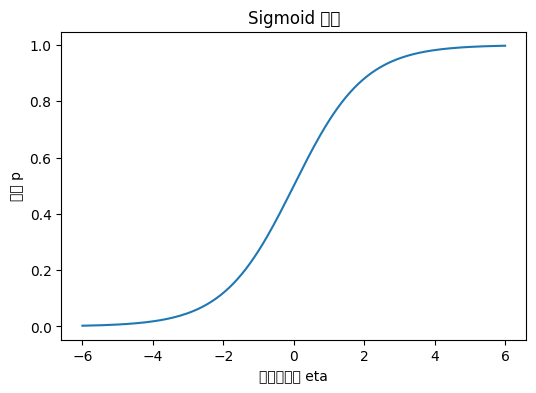

In [3]:
def sigmoid(z):
    """將任意實數轉換成 0 到 1 之間的機率。"""
    z = np.asarray(z)
    return 1 / (1 + np.exp(-z))

z_grid = np.linspace(-6, 6, 200)
p_grid = sigmoid(z_grid)

plt.figure(figsize=(6, 4))
plt.plot(z_grid, p_grid)
plt.xlabel("線性預測值 eta")
plt.ylabel("機率 p")
plt.title("Sigmoid 函數")
plt.show()


## 1.2 建立 log-likelihood

對 Bernoulli 分配而言，每筆觀測值的機率可寫成：

$$
P(y_i|p_i)=p_i^{y_i}(1-p_i)^{1-y_i}
$$

整體 likelihood 為所有觀測機率的乘積。為了計算方便，通常取對數，得到 log-likelihood：

$$
\ell(\beta)=\sum_{i=1}^{n}\left[y_i\log(p_i)+(1-y_i)\log(1-p_i)\right]
$$

在程式中，我們通常最大化 log-likelihood，或等價地最小化 negative log-likelihood。


In [4]:
def negative_log_likelihood(beta, X, y):
    """Logistic regression 的 negative log-likelihood。"""
    eta = X @ beta
    p = sigmoid(eta)

    # 避免 log(0)
    eps = 1e-12
    p = np.clip(p, eps, 1 - eps)

    nll = -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
    return nll

beta_init = np.zeros(X.shape[1])
negative_log_likelihood(beta_init, X, high_load)


np.float64(83.17766166719343)

## 1.3 使用 gradient descent 估計參數

Logistic regression 的 gradient 可寫成：

$$
\nabla \ell(\beta)=X^T(y-p)
$$

若要最小化 negative log-likelihood，則 gradient 為：

$$
\nabla[-\ell(\beta)] = X^T(p-y)
$$

因此，可以用 gradient descent 更新參數：

$$
\beta^{(t+1)}=\beta^{(t)}-\alpha X^T(p-y)
$$

其中 $\alpha$ 是 learning rate。


In [5]:
def fit_logistic_regression_gd(X, y, learning_rate=0.05, n_iter=5000):
    """使用 gradient descent 手動估計 logistic regression。"""
    beta = np.zeros(X.shape[1])
    history = []

    for step in range(n_iter):
        eta = X @ beta
        p = sigmoid(eta)

        gradient = X.T @ (p - y) / len(y)
        beta -= learning_rate * gradient

        if step % 100 == 0:
            history.append({
                "step": step,
                "negative_log_likelihood": negative_log_likelihood(beta, X, y)
            })

    return beta, pd.DataFrame(history)

beta_hat, history = fit_logistic_regression_gd(
    X=X,
    y=high_load,
    learning_rate=0.1,
    n_iter=5000
)

beta_hat


array([-0.656699,  1.36888 ,  1.184613])

In [6]:
history.tail()


,step,negative_log_likelihood
45,4500,58.699859
46,4600,58.699859
47,4700,58.699859
48,4800,58.699859
49,4900,58.699859


/Users/chohsunlu/miniconda3/envs/machinelearning/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chohsunlu/miniconda3/envs/machinelearning/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25986 (\N{CJK UNIFIED IDEOGRAPH-6582}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chohsunlu/miniconda3/envs/machinelearning/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36942 (\N{CJK UNIFIED IDEOGRAPH-904E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chohsunlu/miniconda3/envs/machinelearning/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31243 (\N{CJK UNIFIED IDEOGRAPH-7A0B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chohsunlu/minicon

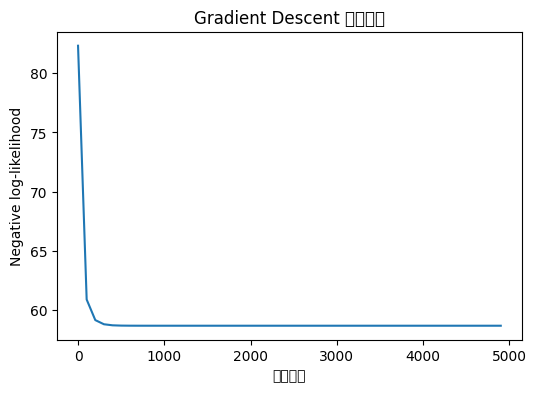

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(history["step"], history["negative_log_likelihood"])
plt.xlabel("迭代次數")
plt.ylabel("Negative log-likelihood")
plt.title("Gradient Descent 收斂過程")
plt.show()


## 1.4 參數解釋與勝算比

在 logit link 下：

$$
\log\left(\frac{p_i}{1-p_i}\right)=x_i^T\beta
$$

因此，$\beta_j$ 表示自變數增加一單位時，log-odds 的改變量。

若取指數：

$$
e^{\beta_j}
$$

則可解釋為 odds ratio。

例如，若某變數的 $e^{\beta_j}=2$，代表該變數增加一單位時，事件發生的 odds 約變成原本的 2 倍。


In [8]:
param_table = pd.DataFrame({
    "參數": ["截距", "任務複雜度", "時間壓力"],
    "beta_hat": beta_hat,
    "odds_ratio": np.exp(beta_hat)
})

param_table


,參數,beta_hat,odds_ratio
0,截距,-0.656699,0.518560
1,任務複雜度,1.368880,3.930945
2,時間壓力,1.184613,3.269422


## 1.5 預測機率與分類

估計參數後，可以計算每筆資料的預測機率：

$$
\hat{p}_i=\frac{1}{1+e^{-x_i^T\hat{\beta}}}
$$

若設定門檻值為 0.5，則：

- $\hat{p}_i \geq 0.5$：預測為 1
- $\hat{p}_i < 0.5$：預測為 0


In [9]:
pred_prob = sigmoid(X @ beta_hat)
pred_class = (pred_prob >= 0.5).astype(int)

accuracy = (pred_class == high_load).mean()

pd.DataFrame({
    "實際值": high_load[:10],
    "預測機率": pred_prob[:10],
    "預測類別": pred_class[:10]
})


,實際值,預測機率,預測類別
0,0,0.189690,0
1,0,0.133780,0
2,1,0.652759,1
3,1,0.903866,1
4,0,0.088012,0
5,0,0.117484,0
6,1,0.777602,1
7,0,0.076011,0
8,1,0.191924,0
9,0,0.051074,0


In [10]:
accuracy


np.float64(0.775)

# Python 實作二：使用 `statsmodels` 的 GLM

這一節使用 `statsmodels` 估計 GLM。`statsmodels.genmod.generalized_linear_model.GLM` 是 statsmodels 提供的 GLM 類別，可以指定 response variable、explanatory variables 與 family；官方文件也說明 `family` 預設為 Gaussian，但可指定 Binomial、Poisson、Gamma 等分配族。

這裡先用與 vanilla 版本相同的資料，估計 Binomial family 搭配 logit link 的 GLM。


In [11]:
import statsmodels.api as sm

X_sm = sm.add_constant(df[["task_complexity", "time_pressure"]])
y_sm = df["high_load"]

glm_binomial = sm.GLM(
    y_sm,
    X_sm,
    family=sm.families.Binomial()
)

glm_binomial_result = glm_binomial.fit()

glm_binomial_result.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              high_load   No. Observations:                  120
Model:                            GLM   Df Residuals:                      117
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -58.700
Date:                Wed, 08 Jul 2026   Deviance:                       117.40
Time:                        21:14:25   Pearson chi2:                     122.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2786
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.6567      0.230     -2.852      0.004      -1.108      -0.205
task_complexity     1.3689      0.345      3.964      0.000       0.692       2.046
time_pressure       1.1846      0.271      4.369      0.000       0.653       1.716
===================================================================================
"""

## 2.1 比較 vanilla 版本與 statsmodels 版本

由於兩者估計方法不完全相同，數值可能不會完全一樣，但方向與大小應大致接近。

`statsmodels` 通常使用較成熟的數值最佳化程序，適合正式分析；vanilla 版本則適合教學與理解演算法。


In [12]:
comparison = pd.DataFrame({
    "參數": ["截距", "任務複雜度", "時間壓力"],
    "Vanilla_GD": beta_hat,
    "statsmodels_GLM": glm_binomial_result.params.values
})

comparison


,參數,Vanilla_GD,statsmodels_GLM
0,截距,-0.656699,-0.656699
1,任務複雜度,1.368880,1.368880
2,時間壓力,1.184613,1.184613


# 3. 延伸範例：Poisson GLM

GLM 的優點在於它不是只能處理二元結果，也可以處理計數資料。

若應變數是計數，例如：

- 一天內發生幾次錯誤
- 一週內收到幾封客訴
- 工地某時段內發生幾次危險動作

可以使用 Poisson family 搭配 log link：

$$
\log(\mu_i)=x_i^T\beta
$$

等價於：

$$
\mu_i=e^{x_i^T\beta}
$$

其中 $\mu_i$ 是事件次數的期望值。


In [13]:
rng = np.random.default_rng(123)

n_count = 150
workload = rng.normal(0, 1, n_count)
noise_level = rng.normal(0, 1, n_count)

X_count = np.column_stack([
    np.ones(n_count),
    workload,
    noise_level
])

beta_count_true = np.array([1.0, 0.5, 0.3])
mu = np.exp(X_count @ beta_count_true)

error_count = rng.poisson(mu)

df_count = pd.DataFrame({
    "workload": workload,
    "noise_level": noise_level,
    "error_count": error_count,
    "true_mu": mu
})

df_count.head()


,workload,noise_level,error_count,true_mu
0,-0.989121,0.100215,2,1.708309
1,-0.367787,-0.560110,1,1.911855
2,1.287925,-1.031298,4,3.798375
3,0.193974,0.476529,4,3.455426
4,0.920231,-0.853250,2,3.333892


In [14]:
X_count_sm = sm.add_constant(df_count[["workload", "noise_level"]])
y_count_sm = df_count["error_count"]

glm_poisson = sm.GLM(
    y_count_sm,
    X_count_sm,
    family=sm.families.Poisson()
)

glm_poisson_result = glm_poisson.fit()

glm_poisson_result.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:            error_count   No. Observations:                  150
Model:                            GLM   Df Residuals:                      147
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -297.08
Date:                Wed, 08 Jul 2026   Deviance:                       179.08
Time:                        21:14:25   Pearson chi2:                     160.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.5982
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.0784      0.051     21.053      0.000       0.978       1.179
workload        0.4489      0.049      9.174      0.000       0.353       0.545
noise_level     0.3568      0.045      7.862      0.000       0.268       0.446
===============================================================================
"""

## 3.1 Poisson GLM 的參數解釋

Poisson GLM 使用 log link 時：

$$
\log(\mu_i)=x_i^T\beta
$$

因此，若某個自變數增加一單位，$\mu$ 的倍數變化為：

$$
e^{\beta_j}
$$

例如，若 $e^{\beta_j}=1.5$，代表該變數增加一單位時，預期事件次數約變成原本的 1.5 倍。


In [15]:
poisson_param_table = pd.DataFrame({
    "參數": glm_poisson_result.params.index,
    "beta": glm_poisson_result.params.values,
    "exp(beta)": np.exp(glm_poisson_result.params.values)
})

poisson_param_table


,參數,beta,exp(beta)
0,const,1.078443,2.940098
1,workload,0.448905,1.566595
2,noise_level,0.356790,1.428736


# 4. GLM 分析時的基本檢查

GLM 不只看係數是否顯著，也應該檢查模型是否合理。

常見檢查包含：

1. 分配族是否符合應變數型態。
2. link function 是否合理。
3. 是否有過度離散，例如 Poisson 模型中變異數明顯大於平均數。
4. 是否有極端值或高影響力觀測。
5. 樣本數是否足以支撐模型複雜度。
6. 自變數之間是否存在嚴重共線性。

在小樣本研究中，GLM 的結果應更謹慎解釋。若樣本數很小，模型收斂、估計穩定性、標準誤與 p 值都可能受到影響。


In [16]:
mean_count = df_count["error_count"].mean()
var_count = df_count["error_count"].var()

pd.DataFrame({
    "指標": ["平均數", "變異數", "變異數 / 平均數"],
    "數值": [mean_count, var_count, var_count / mean_count]
})


,指標,數值
0,平均數,3.493333
1,變異數,7.540224
2,變異數 / 平均數,2.158461


# 5. 小結

本 Notebook 將 GLM 的概念、數學推導與 Python 實作連接起來。

重點如下：

1. GLM 將線性預測式、link function 與分配族整合在同一個架構中。
2. Logistic regression 是 Binomial family 搭配 logit link 的 GLM。
3. Poisson regression 是 Poisson family 搭配 log link 的 GLM。
4. Vanilla 版本有助於理解 likelihood、gradient 與預測機率的計算邏輯。
5. `statsmodels.GLM` 適合正式估計與產生統計摘要。
6. 在研究應用中，應根據應變數型態選擇合適的 family 與 link function。

若應變數是連續且近似常態，可考慮 Gaussian GLM 或一般線性迴歸；若應變數是二元結果，可考慮 Binomial-logit GLM；若應變數是計數資料，可考慮 Poisson-log GLM，並進一步檢查是否有過度離散。
